```{=html}
<style>
/* Keep notebook logging visible in Jupyter but hide stdout blocks in rendered HTML. */
.quarto-document-content .cell-output-stdout {
  display: none;
}
</style>
```

In [1]:
#| output: false
#| eval: true
#| include: false
#| context: setup

import json
from pathlib import Path
import requests

# --- Configuration ---
ZOTERO_GROUP_ID = 5985739
OUTFILE = "../files/zotero_group_library.bib"
ZOTERO_JSON_OUTFILE = "../files/zotero-items.json"

# Zotero group API URL for BibTeX output
url = f"https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=biblatex&limit=5000"
zotero_json_url = f"https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=json&limit=100"


def resolve_zotero_items_path():
    cwd = Path.cwd()
    path_candidates = [
        cwd / "../files/zotero-items.json",
        cwd / "card-lab.github.io/files/zotero-items.json",
        cwd / "files/zotero-items.json",
    ]

    for candidate in path_candidates:
        if candidate.exists():
            return candidate.resolve()

    return path_candidates[0].resolve()


# Zotero returns results paginated — we'll loop until no "next" link
def download_full_bibtex():
    session = requests.Session()
    all_bib = ""
    next_url = url

    while next_url:
        print(f"Fetching: {next_url}")
        r = session.get(next_url)
        if r.status_code != 200:
            raise RuntimeError(f"Error {r.status_code}: {r.text}")

        # Append BibTeX text
        all_bib += r.text.strip() + "\n\n"

        # Check for pagination
        links = r.links
        if "next" in links:
            next_url = links["next"]["url"]
        else:
            next_url = None

    return all_bib


def download_full_zotero_items():
    session = requests.Session()
    items = []
    next_url = zotero_json_url

    while next_url:
        print(f"Fetching Zotero JSON: {next_url}")
        r = session.get(next_url, timeout=30)
        if r.status_code != 200:
            raise RuntimeError(f"Error {r.status_code}: {r.text}")

        items.extend(r.json())

        links = r.links
        if "next" in links:
            next_url = links["next"]["url"]
        else:
            next_url = None

    return items


def load_zotero_items():
    zotero_items_path = resolve_zotero_items_path()
    if zotero_items_path.exists():
        with open(zotero_items_path, "r", encoding="utf-8") as f:
            return json.load(f)

    items = download_full_zotero_items()
    zotero_items_path.parent.mkdir(parents=True, exist_ok=True)
    with open(zotero_items_path, "w", encoding="utf-8") as f:
        json.dump(items, f, ensure_ascii=True, indent=2)
    print(f"Saved fallback Zotero JSON to {zotero_items_path}")
    return items


if __name__ == "__main__":
    bibtex_data = download_full_bibtex()
    with open(OUTFILE, "w", encoding="utf-8") as f:
        f.write(bibtex_data)
    print(f"Saved Zotero library to {OUTFILE}")

%conda install bibtexparser wordcloud

Fetching: https://api.zotero.org/groups/5985739/items?format=biblatex&limit=5000


Fetching: https://api.zotero.org/groups/5985739/items?format=biblatex&limit=100&start=100


Saved Zotero library to ../files/zotero_group_library.bib


Retrieving notices: - 

\ 

...

| 

/ 

done




==> WARNING: A newer version of conda exists. <==
  current version: 26.5.0
  latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c conda-forge conda

Or to minimize the number of packages updated during conda update use

     conda install conda=26.5.2



# All requested packages already installed.

WARNING conda.conda_pypi.main:notify_externally_managed_future(209): 
  This environment has pip installed. A future conda release will
  protect conda environments from accidental 'pip install' usage.
  Try the beta to install PyPI packages natively with conda:
    conda config --set solver rattler
    conda config --append channels conda-pypi
    conda install <package>
  More info: https://docs.conda.io/projects/conda/en/stable/new-features.html



Note: you may need to restart the kernel to use updated packages.


## At a glance

In [2]:
#| echo: false
#| output: true
#| eval: true

import json
from pathlib import Path
import requests
import plotly.graph_objects as go
import numpy as np
from IPython.display import HTML


def make_sparkline(data, color="white"):
    """Return Plotly sparkline HTML."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        y=data, mode="lines", line=dict(color=color, width=2)
    ))
    fig.update_layout(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        margin=dict(l=0, r=0, t=0, b=0),
        height=80,
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)"
    )
    return fig.to_html(include_plotlyjs=False, full_html=False)


def make_value_box(title, value, icon_name, theme, decimals=1):
    """Return HTML for a value box with an icon."""
    return f"""
    <div class="value-box {theme}">
      <div class="top-row">
        <div class="label">{title}</div>
        <iconify-icon icon="{icon_name}"></iconify-icon>
      </div>
      <div class="value">{value:.{decimals}f}</div>
    </div>
    """


ZOTERO_GROUP_ID = 5985739


def load_zotero_items_for_counts():
    cwd = Path.cwd()
    path_candidates = [
        cwd / '../files/zotero-items.json',
        cwd / 'card-lab.github.io/files/zotero-items.json',
        cwd / 'files/zotero-items.json',
    ]

    found = next((p.resolve() for p in path_candidates if p.exists()), None)
    if found is not None:
        with open(found, encoding='utf-8') as f:
            items = json.load(f)
        return items

    api_url = f'https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=json&limit=100'
    session = requests.Session()
    items = []
    next_url = api_url

    while next_url:
        r = session.get(next_url, timeout=30)
        r.raise_for_status()
        items.extend(r.json())
        next_url = r.links.get('next', {}).get('url')

    return items


def count_in_zotero(items, item_types):
    wanted = {item_type.strip().lower() for item_type in item_types}
    count = 0
    for item in items:
        data = item.get("data", {})
        item_type = str(data.get("itemType", "")).strip().lower()
        if item_type in wanted:
            count += 1
    return count


zotero_items = load_zotero_items_for_counts()

# Get stats from Zotero JSON item types instead of BibTeX entry tags.
npres = count_in_zotero(zotero_items, ["presentation", "conferencepaper"])
ntheses = count_in_zotero(zotero_items, ["thesis"])
npapers = count_in_zotero(zotero_items, ["journalarticle"])
ncod = count_in_zotero(zotero_items, ["computerprogram", "dataset"])

# Build multiple boxes
boxes_html = f"""
<div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(450px,1fr));gap:1rem;">
  {make_value_box("Peer-reviewed papers published since 2022", npapers, "fluent:document-sparkle-24-regular", "success", decimals=0)}
  {make_value_box("Conference presentations given since 2022", npres, "hugeicons:presentation-online", "info", decimals=0)}
  {make_value_box("Theses & dissertations published since 2022", ntheses, "lets-icons:book-fill", "warning", decimals=0)}
  {make_value_box("Datasets and open-source codes published since 2022", ncod, "carbon:db2-data-sharing-group", "danger", decimals=0)}
</div>
"""

HTML(boxes_html)

## Word cloud from titles and abstracts

In [3]:
#| output: false
#| echo: false

import json
import csv
from pathlib import Path
import requests
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ----------------------------
# Configuration
# ----------------------------
ZOTERO_GROUP_ID = 5985739
def load_word_cloud_exclusions():
    path_candidates = [
        Path("../files/word-cloud-exclusions-list.csv"),
        Path("files/word-cloud-exclusions-list.csv"),
    ]
    for candidate in path_candidates:
        if not candidate.exists():
            continue
        words = set()
        with candidate.open("r", encoding="utf-8", newline="") as f:
            reader = csv.DictReader(f)
            for row in reader:
                word = str((row or {}).get("word") or "").strip().lower()
                if word:
                    words.add(word)
        if words:
            return sorted(words)
    return []

exclude_terms = load_word_cloud_exclusions()


def load_zotero_items():
    cwd = Path.cwd()
    path_candidates = [
        cwd / '../files/zotero-items.json',
        cwd / 'card-lab.github.io/files/zotero-items.json',
        cwd / 'files/zotero-items.json',
    ]

    found = next((p.resolve() for p in path_candidates if p.exists()), None)
    if found is not None:
        with open(found, encoding='utf-8') as f:
            items = json.load(f)
        print(f'Loaded Zotero items from file: {found}')
        return items

    # Fallback: fetch directly from Zotero API if local JSON is not present.
    api_url = f'https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=json&limit=100'
    session = requests.Session()
    items = []
    next_url = api_url

    while next_url:
        r = session.get(next_url, timeout=30)
        r.raise_for_status()
        items.extend(r.json())
        next_url = r.links.get('next', {}).get('url')

    if not items:
        candidate_text = '\n'.join(str(p.resolve()) for p in path_candidates)
        raise FileNotFoundError(
            'Could not locate local zotero-items.json and API fetch returned no records. Tried:\n' + candidate_text
        )

    print(f'Loaded Zotero items from API: {len(items)} records')
    return items


# ----------------------------
# Step 1: Read Zotero records
# ----------------------------
zotero_items = load_zotero_items()

# ----------------------------
# Step 2: Extract documents (title + abstract + tags)
# Includes theses/software/reports and other non-attachment item types.
# ----------------------------
documents = []
included_types = set()

for item in zotero_items:
    data = item.get('data', {})
    item_type = str(data.get('itemType', '')).strip().lower()

    # Skip non-scholarly container records.
    if item_type in {'attachment', 'note', 'annotation'}:
        continue

    text_parts = []

    title = str(data.get('title', '')).strip()
    abstract = str(data.get('abstractNote', '')).strip()
    tags = [
        str(t.get('tag', '')).strip()
        for t in data.get('tags', [])
        if str(t.get('tag', '')).strip()
    ]

    if title:
        text_parts.append(title)
    if abstract:
        text_parts.append(abstract)
    if tags:
        text_parts.append(' '.join(tags))

    if text_parts:
        documents.append(' '.join(text_parts))
        included_types.add(item_type or 'unknown')

if not documents:
    raise ValueError('No textual Zotero records found for word cloud generation.')

print(f'Loaded {len(documents)} textual Zotero records from {len(included_types)} item types.')
print('Included item types:', ', '.join(sorted(included_types)))

# ----------------------------
# Step 3: Compute TF-IDF
# ----------------------------
vectorizer = TfidfVectorizer(
    stop_words='english',
    lowercase=True,
    token_pattern=r'(?u)\b[a-zA-Z]{2,}\b'
)

tfidf_matrix = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()

# Compute total TF-IDF score per term (sum over all documents)
scores = tfidf_matrix.sum(axis=0).A1
tfidf_scores = dict(zip(feature_names, scores))

# Remove excluded terms
for term in exclude_terms:
    tfidf_scores.pop(term.lower(), None)

# ----------------------------
# Step 4: Create Word Cloud
# ----------------------------
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    collocations=False
).generate_from_frequencies(tfidf_scores)




Loaded Zotero items from file: /Users/paytone/Library/CloudStorage/OneDrive-UniversityofCincinnati/Code/card-lab/card-lab.github.io/files/zotero-items.json
Loaded 102 textual Zotero records from 8 item types.
Included item types: computerprogram, conferencepaper, journalarticle, manuscript, preprint, presentation, report, thesis


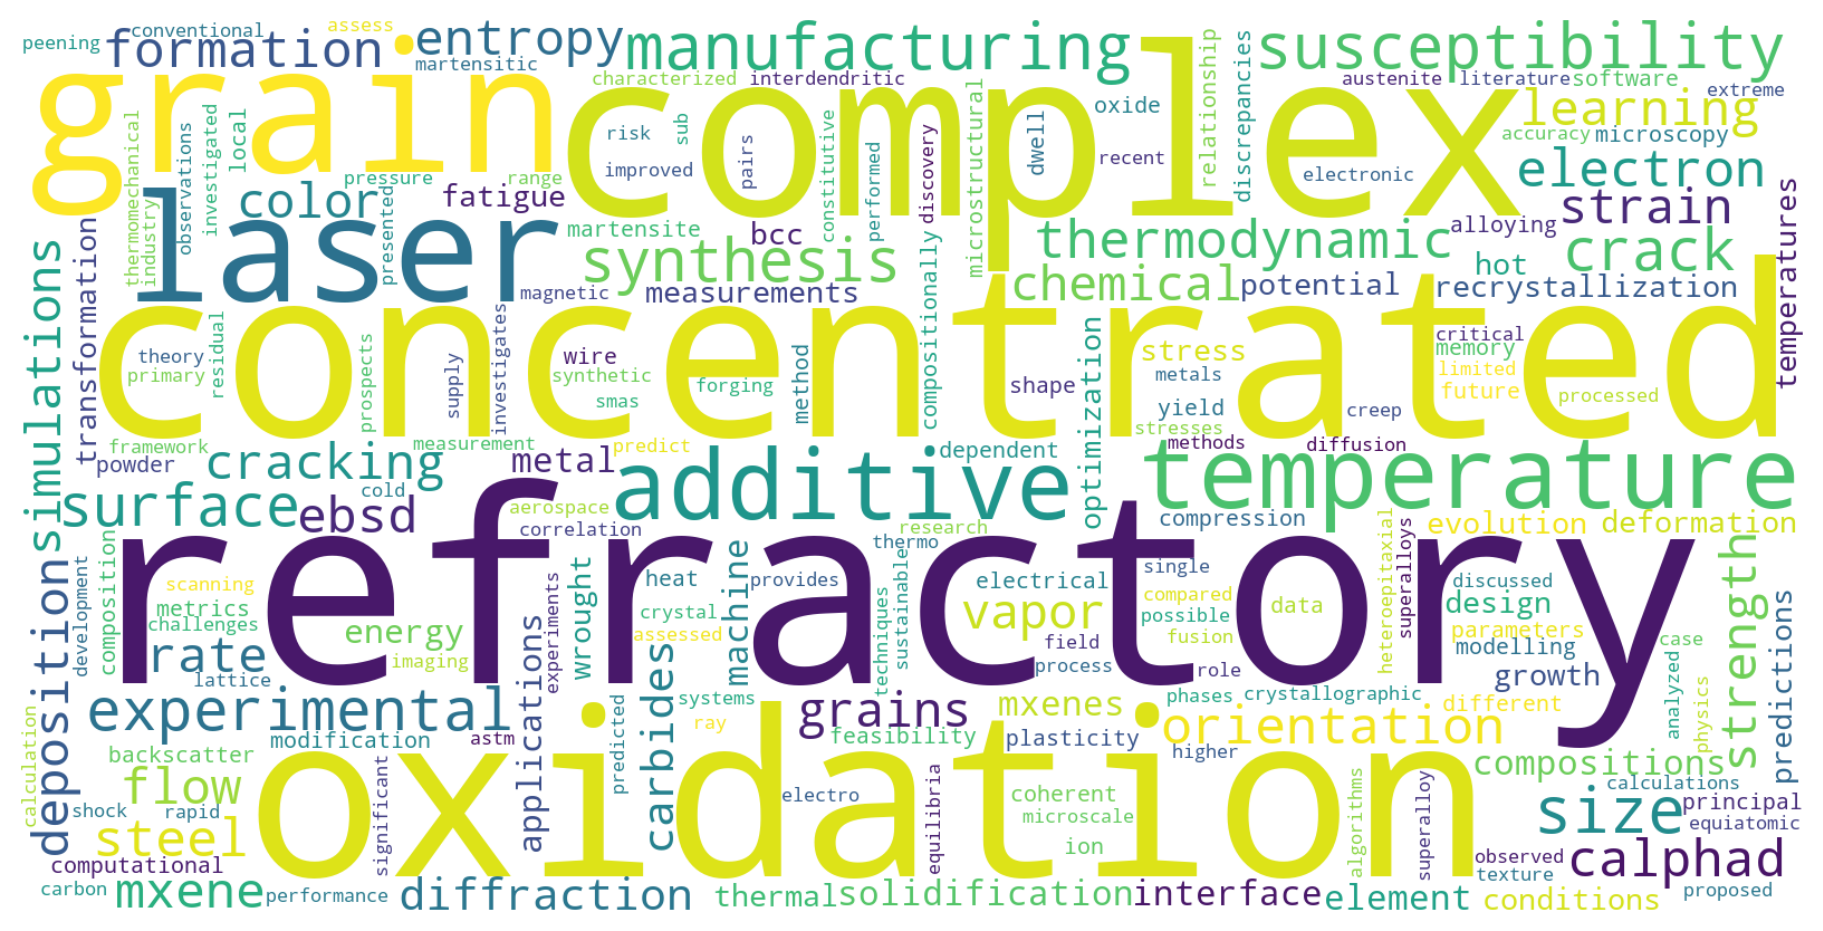

In [4]:
#| echo: false
#| output: true

# ----------------------------
# Step 5: Display
# ----------------------------
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [5]:
#| output: false
#| eval: true
#| include: false
#| context: setup

import json
import requests
import pandas as pd
import time
from pathlib import Path

# ----------------------------
# Config
# ----------------------------
ZOTERO_GROUP_ID = 5985739
REFERENCES_WE_CITED_CSV_PATH = Path("../files/references_card-lab_cited.csv")
REFERENCE_COLUMNS = [
    "citing_doi",
    "ref_doi",
    "ref_key",
    "ref_author",
    "ref_year",
    "ref_title",
    "ref_journal",
    "raw",
]


def load_reference_source_items():
    cwd = Path.cwd()
    path_candidates = [
        cwd / '../files/zotero-items.json',
        cwd / 'card-lab.github.io/files/zotero-items.json',
        cwd / 'files/zotero-items.json',
    ]

    found = next((p.resolve() for p in path_candidates if p.exists()), None)
    if found is not None:
        with open(found, encoding='utf-8') as f:
            return json.load(f)

    api_url = f'https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=json&limit=100'
    session = requests.Session()
    items = []
    next_url = api_url

    while next_url:
        r = session.get(next_url, timeout=30)
        r.raise_for_status()
        items.extend(r.json())
        next_url = r.links.get('next', {}).get('url')

    return items


zotero_items = load_reference_source_items()
dois = sorted({
    str(item.get("data", {}).get("DOI", "")).strip().lower().replace("https://doi.org/", "").replace("http://doi.org/", "")
    for item in zotero_items
    if str(item.get("data", {}).get("DOI", "")).strip()
})

email = "paytonej@ucmail.uc.edu"  # Recommended for polite API usage
delay_seconds = 1.0               # Pause between requests to avoid rate limiting

if REFERENCES_WE_CITED_CSV_PATH.exists():
    existing_refs_df = pd.read_csv(REFERENCES_WE_CITED_CSV_PATH)
else:
    existing_refs_df = pd.DataFrame(columns=REFERENCE_COLUMNS)

for column in REFERENCE_COLUMNS:
    if column not in existing_refs_df.columns:
        existing_refs_df[column] = pd.NA


def _has_complete_reference_rows(df):
    if df.empty:
        return False

    completeness = df[REFERENCE_COLUMNS].fillna("").astype(str).apply(lambda col: col.str.strip() != "")
    return bool(completeness.all(axis=1).all())


# ----------------------------
# Helper function to get references for a DOI
# ----------------------------
def get_references_for_doi(doi):
    cached_rows = existing_refs_df.loc[existing_refs_df["citing_doi"] == doi].copy()
    if _has_complete_reference_rows(cached_rows):
        print(f"Using cached complete references for {doi}")
        return cached_rows[REFERENCE_COLUMNS].to_dict("records")

    url = f"https://api.crossref.org/works/{doi}"
    headers = {"User-Agent": f"Python script (mailto:{email})"}
    r = requests.get(url, headers=headers)

    if r.status_code != 200:
        print(f"Failed to fetch {doi}: HTTP {r.status_code}")
        return []

    data = r.json().get("message", {})
    references = data.get("reference", [])

    ref_list = []
    for ref in references:
        ref_list.append({
            "citing_doi": doi,
            "ref_doi": ref.get("DOI"),
            "ref_key": ref.get("key"),
            "ref_author": ref.get("author"),
            "ref_year": ref.get("year"),
            "ref_title": ref.get("article-title"),
            "ref_journal": ref.get("journal-title"),
            "raw": ref.get("unstructured")  # fallback
        })

    return ref_list

# ----------------------------
# Main script
# ----------------------------
all_refs = []
for doi in dois:
    refs = get_references_for_doi(doi)
    all_refs.extend(refs)
    time.sleep(delay_seconds)  # be polite to the API

df_refs = pd.DataFrame(all_refs)

# Save to CSV for later analysis
df_refs.to_csv("../files/references_card-lab_cited.csv", index=False)

print(f"Loaded {len(dois)} DOI(s) from Zotero records")
print(df_refs)

Failed to fetch 10.21949/rfzv-6285: HTTP 404


Failed to fetch 10.21949/tzgj-rk36: HTTP 404


Failed to fetch 10.5281/zenodo.16541961: HTTP 404


Loaded 22 DOI(s) from Zotero records
                       citing_doi                           ref_doi ref_key  \
0    10.1007/978-3-031-63937-1_73                              None  73_CR1   
1    10.1007/978-3-031-63937-1_73     10.1016/S0142-1123(97)00034-0  73_CR2   
2    10.1007/978-3-031-63937-1_73     10.1016/j.actamat.2012.01.049  73_CR3   
3    10.1007/978-3-031-63937-1_73      10.1016/j.matdes.2018.02.048  73_CR4   
4    10.1007/978-3-031-63937-1_73  10.1016/j.scriptamat.2017.04.018  73_CR5   
..                            ...                               ...     ...   
851            10.3390/ma16041549      10.1016/0375-9601(75)90130-9  ref_91   
852            10.3390/ma16041549        10.1088/0305-4470/16/4/016  ref_92   
853            10.3390/ma16041549         10.1007/s11467-013-0403-z  ref_93   
854            10.3390/ma16041549          10.1103/PhysRev.133.A310  ref_94   
855            10.3390/ma16041549        10.1088/0370-1328/83/3/118  ref_95   

        ref_au

In [6]:
import pandas as pd
import json
import re
import requests
from typing import Optional, Tuple, List, Dict
import time
import numpy as np

# Geographic bounding boxes for major countries (lon_min, lon_max, lat_min, lat_max)
COUNTRY_BOUNDS = {
    'China': {'lon_min': 73, 'lon_max': 135, 'lat_min': 18, 'lat_max': 54},
    'United States': {'lon_min': -130, 'lon_max': -60, 'lat_min': 18, 'lat_max': 50},
    'United States of America': {'lon_min': -130, 'lon_max': -60, 'lat_min': 18, 'lat_max': 50},
    'Canada': {'lon_min': -145, 'lon_max': -50, 'lat_min': 40, 'lat_max': 85},
    'Australia': {'lon_min': 112, 'lon_max': 155, 'lat_min': -45, 'lat_max': -10},
    'Japan': {'lon_min': 125, 'lon_max': 150, 'lat_min': 30, 'lat_max': 46},
    'India': {'lon_min': 68, 'lon_max': 97, 'lat_min': 8, 'lat_max': 37},
    'Brazil': {'lon_min': -75, 'lon_max': -35, 'lat_min': -33, 'lat_max': 5},
    'Germany': {'lon_min': 5, 'lon_max': 16, 'lat_min': 47, 'lat_max': 56},
    'France': {'lon_min': -8, 'lon_max': 8, 'lat_min': 42, 'lat_max': 52},
    'United Kingdom': {'lon_min': -8, 'lon_max': 2, 'lat_min': 50, 'lat_max': 59},
    'Russia': {'lon_min': 20, 'lon_max': 180, 'lat_min': 40, 'lat_max': 82},
    'South Korea': {'lon_min': 124, 'lon_max': 132, 'lat_min': 33, 'lat_max': 44},
    'Czechia': {'lon_min': 12, 'lon_max': 19, 'lat_min': 48, 'lat_max': 51},
    'Czech Republic': {'lon_min': 12, 'lon_max': 19, 'lat_min': 48, 'lat_max': 51},
}

def _is_coordinate_in_bounds(lat: float, lon: float, country: str) -> bool:
    """Check if a coordinate is within expected bounds for a country."""
    if pd.isna(country) or not country:
        return True  # No country specified, accept coordinate
    
    # Normalize country name
    country_norm = str(country).strip()
    for key in COUNTRY_BOUNDS:
        if key.lower() in country_norm.lower() or country_norm.lower() in key.lower():
            bounds = COUNTRY_BOUNDS[key]
            return (bounds['lon_min'] <= lon <= bounds['lon_max'] and
                    bounds['lat_min'] <= lat <= bounds['lat_max'])
    
    # If country not in COUNTRY_BOUNDS, accept the coordinate
    return True

def _filter_out_of_bounds_coordinates(df: pd.DataFrame) -> pd.DataFrame:
    """Filter out coordinates that don't match their declared country location."""
    if df.empty:
        return df
    
    # Create a mask for valid coordinates
    valid_mask = df.apply(
        lambda row: (
            pd.isna(row['latitude']) or pd.isna(row['longitude']) or
            _is_coordinate_in_bounds(row['latitude'], row['longitude'], row['affiliation_country'])
        ),
        axis=1
    )
    
    removed_count = (~valid_mask).sum()
    if removed_count > 0:
        print(f"Filtered out {removed_count} out-of-bounds coordinate(s) based on country location checks.")
    
    return df[valid_mask].reset_index(drop=True)

def normalize_doi(doi):
    """Normalize a DOI string."""
    if not doi or not str(doi).strip():
        return None
    doi_str = str(doi).lower().strip()
    if doi_str.startswith("http"):
        if "doi.org/" in doi_str:
            doi_str = doi_str.split("doi.org/")[-1]
        elif "doi/" in doi_str:
            doi_str = doi_str.split("doi/")[-1]
    if doi_str.startswith("doi:"):
        doi_str = doi_str[4:]
    return doi_str if doi_str else None

def _normalize_country_name(name: Optional[str]) -> Optional[str]:
    """Normalize a country name for matching."""
    if not name:
        return None
    normalized = str(name).lower().strip()
    normalized = re.sub(r"\s+", " ", normalized)
    normalized = re.sub(r"[^\w\s]", "", normalized)
    return normalized if normalized else None

def _deserialize_location_entries(json_str: str) -> list:
    """Deserialize location entries from JSON string."""
    if pd.isna(json_str) or (isinstance(json_str, str) and not json_str.strip()):
        return []
    try:
        return json.loads(json_str) if isinstance(json_str, str) else json_str
    except (json.JSONDecodeError, TypeError):
        return []

def _serialize_location_entries(entries: list) -> str:
    """Serialize location entries to JSON string."""
    if not entries:
        return json.dumps([])
    return json.dumps(entries, ensure_ascii=False)

def _dedupe_location_entries(entries: list) -> list:
    """Remove duplicate location entries, keeping the best source."""
    if not entries:
        return []
    
    seen = {}
    source_priority = {"openalex_search": 1, "country_representative_point": 2, "row_mean_fallback": 3}
    
    for entry in entries:
        key = (entry.get("latitude"), entry.get("longitude"))
        if key not in seen:
            seen[key] = entry
        else:
            # Keep entry with higher priority (lower number = better)
            current_priority = source_priority.get(entry.get("source"), 999)
            existing_priority = source_priority.get(seen[key].get("source"), 999)
            if current_priority < existing_priority:
                seen[key] = entry
    
    return list(seen.values())

def _search_openalex_institution_geo(affiliation_text: str, country_hint: Optional[str] = None, session=None, cache=None) -> Optional[Tuple[float, float, str]]:
    """Search OpenAlex for institution geolocation."""
    if not affiliation_text or not session or cache is None:
        return None
    
    cache_key = f"openalex_{affiliation_text}_{country_hint}"
    if cache_key in cache:
        return cache[cache_key]
    
    try:
        params = {"filter": f'display_name.search:"{affiliation_text}"', "per_page": 1}
        response = session.get("https://api.openalex.org/institutions", params=params, timeout=5)
        if response.status_code == 200:
            data = response.json()
            if data.get("results"):
                inst = data["results"][0]
                geo = inst.get("geo")
                if geo and geo.get("latitude") is not None and geo.get("longitude") is not None:
                    result = (geo["latitude"], geo["longitude"], inst.get("display_name", ""))
                    cache[cache_key] = result
                    return result
    except Exception:
        pass
    
    cache[cache_key] = None
    return None

def _load_country_centroid_lookup() -> dict:
    """Load country centroids and continents."""
    try:
        import geopandas as gpd
        from cartopy.io import shapereader
        
        world_path = shapereader.natural_earth(resolution="110m", category="cultural", name="admin_0_countries")
        world = gpd.read_file(world_path)[["NAME_EN", "ADMIN", "CONTINENT"]]
        
        country_lookup = {}
        for _, row in world.iterrows():
            for country_name in [row.get("NAME_EN"), row.get("ADMIN")]:
                if country_name:
                    norm = _normalize_country_name(country_name)
                    if norm:
                        country_lookup[norm] = {
                            "continent": row.get("CONTINENT", "Unknown"),
                            "centroid": None
                        }
        
        # Add aliases
        aliases = {
            "united states": "united states of america",
            "usa": "united states of america",
            "uk": "united kingdom",
            "czechia": "czech republic",
            "the netherlands": "netherlands",
            "turkiye": "turkey",
            "south korea": "republic of korea",
        }
        for alias, canonical in aliases.items():
            canonical_norm = _normalize_country_name(canonical)
            if canonical_norm in country_lookup:
                country_lookup[_normalize_country_name(alias)] = country_lookup[canonical_norm]
        
        return country_lookup
    except Exception as e:
        print(f"Warning: Failed to load country centroid lookup: {e}")
        return {}

def _build_location_entries_from_text(affiliation_text: str, country_text: str, lat: float, lon: float, country_lookup: dict, session=None, search_cache=None) -> list:
    """Build location entries from affiliation text with fallback chain."""
    if search_cache is None:
        search_cache = {}
    
    entries = []
    countries = [c.strip() for c in str(country_text).split(";") if c.strip()] if pd.notna(country_text) else []
    affiliations = [a.strip() for a in str(affiliation_text).split(";") if a.strip()] if pd.notna(affiliation_text) else []
    
    for i, affiliation in enumerate(affiliations):
        country = countries[i] if i < len(countries) else (countries[0] if countries else "Unknown")
        entry = None
        
        # Try OpenAlex search
        if session:
            result = _search_openalex_institution_geo(affiliation, country, session, search_cache)
            if result:
                entry = {
                    "affiliation": affiliation,
                    "country": country,
                    "latitude": result[0],
                    "longitude": result[1],
                    "city": result[2],
                    "source": "openalex_search"
                }
        
        # Fallback to country representative point
        if not entry and country:
            country_norm = _normalize_country_name(country)
            if country_norm in country_lookup:
                continent = country_lookup[country_norm].get("continent", "Unknown")
                # Use the most central country coordinate as representative point (approximate)
                # For production, should use actual centroid from database
                entry = {
                    "affiliation": affiliation,
                    "country": country,
                    "latitude": None,
                    "longitude": None,
                    "source": "country_representative_point"
                }
        
        # Final fallback to row mean
        if not entry and not pd.isna(lat) and not pd.isna(lon):
            entry = {
                "affiliation": affiliation,
                "country": country,
                "latitude": lat,
                "longitude": lon,
                "source": "row_mean_fallback"
            }
        
        if entry:
            entries.append(entry)
    
    return entries

def _location_entries_from_rows(group_df: pd.DataFrame) -> list:
    """Extract location entries from a group of rows."""
    entries = []
    for _, row in group_df.iterrows():
        if pd.notna(row['latitude']) and pd.notna(row['longitude']):
            entries.append({
                "affiliation": row['affiliation'],
                "country": row['affiliation_country'],
                "latitude": row['latitude'],
                "longitude": row['longitude'],
                "city": row.get('affiliation_city', ''),
                "state": row.get('affiliation_state', ''),
                "source": "row_based"
            })
    return entries

def build_comprehensive_rows(dois: list, country_lookup: dict = None, session=None, search_cache=None) -> list:
    """Fetch author institution affiliations from OpenAlex and return geocoded rows."""
    if country_lookup is None:
        country_lookup = _load_country_centroid_lookup()
    if session is None:
        session = requests.Session()
    if search_cache is None:
        search_cache = {}

    _OPENALEX_EMAIL = "paytonej@ucmail.uc.edu"
    _headers = {"User-Agent": f"CARD Lab bibliometrics (mailto:{_OPENALEX_EMAIL})"}
    rows = []

    for doi in dois:
        url = f"https://api.openalex.org/works/doi:{doi}"
        try:
            resp = session.get(url, headers=_headers, params={"mailto": _OPENALEX_EMAIL}, timeout=15)
            if resp.status_code != 200:
                continue
            work = resp.json()
        except Exception:
            continue

        seen: set = set()
        for authorship in work.get("authorships", []) or []:
            for inst in authorship.get("institutions", []) or []:
                name = str(inst.get("display_name") or "").strip()
                country_code = str(inst.get("country_code") or "").strip()
                if not name:
                    continue
                key = (name, country_code)
                if key in seen:
                    continue
                seen.add(key)

                lat = lon = city = region = None
                geo = inst.get("geo") or {}
                if geo.get("latitude") is not None and geo.get("longitude") is not None:
                    lat = float(geo["latitude"])
                    lon = float(geo["longitude"])
                    city = str(geo.get("city") or "").strip()
                    region = str(geo.get("region") or "").strip()

                if lat is None:
                    result = _search_openalex_institution_geo(name, country_code, session, search_cache)
                    if result:
                        lat, lon, city = result[0], result[1], result[2]
                        region = ""

                rows.append({
                    "doi": doi,
                    "affiliation": name,
                    "affiliation_city": city or "",
                    "affiliation_state": region or "",
                    "affiliation_country": country_code,
                    "latitude": lat,
                    "longitude": lon,
                    "author_name": "",
                })

        time.sleep(0.05)

    return rows

def build_map_rows_from_aggregates(df: pd.DataFrame, locations_col: str = None, doi_col: str = "ref_doi", affiliation_col: str = "ref_affiliations", country_col: str = "ref_affiliation_countries", lat_col: str = "ref_latitude_mean", lon_col: str = "ref_longitude_mean") -> pd.DataFrame:
    """Build map rows from an aggregate dataframe, using stored locations or building from text."""
    country_lookup = _load_country_centroid_lookup()
    session = requests.Session()
    search_cache = {}
    rows = []
    
    for _, row in df.iterrows():
        doi = normalize_doi(row.get(doi_col))
        if not doi:
            continue
        
        entries = []
        if locations_col and locations_col in row.index:
            entries = _dedupe_location_entries(
                _deserialize_location_entries(row.get(locations_col))
            )
        
        if not entries:
            entries = _build_location_entries_from_text(
                row.get(affiliation_col),
                row.get(country_col),
                row.get(lat_col),
                row.get(lon_col),
                country_lookup,
                session,
                search_cache,
            )
        
        for entry in entries:
            rows.append({
                "doi": doi,
                "affiliation": entry.get("affiliation") or entry.get("country") or "Unknown",
                "affiliation_city": entry.get("city", ""),
                "affiliation_state": entry.get("state", ""),
                "affiliation_country": entry.get("country", ""),
                "latitude": entry.get("latitude"),
                "longitude": entry.get("longitude"),
                "author_name": "",
            })
    
    return pd.DataFrame(rows)

def write_plotly_affiliation_map(df, output_html_path, title):
    """Generate a Plotly scatter_geo map from a build_comprehensive_rows dataframe."""
    if df.empty:
        print(f"Warning: no data to plot for '{title}'.")
        return
    
    # Filter out-of-bounds coordinates based on country
    df = _filter_out_of_bounds_coordinates(df)
    
    grouped = (
        df.groupby(
            [
                "affiliation",
                "latitude",
                "longitude",
                "affiliation_city",
                "affiliation_state",
                "affiliation_country",
            ],
            dropna=False,
        )
        .agg(
            papers=("doi", "nunique"),
            researchers=("author_name", "nunique"),
            records=("author_name", "size"),
        )
        .reset_index()
    )
    
    grouped["location_label"] = grouped.apply(
        lambda row: ", ".join(
            part
            for part in [
                str(row.get("affiliation_city", "")).strip(),
                str(row.get("affiliation_state", "")).strip(),
                str(row.get("affiliation_country", "")).strip(),
            ]
            if part
        ),
        axis=1,
    )
    
    grouped["continent"] = "Unknown"
    try:
        import geopandas as gpd
        from cartopy.io import shapereader
        from shapely.geometry import Point
        
        world_path = shapereader.natural_earth(
            resolution="110m",
            category="cultural",
            name="admin_0_countries",
        )
        world = gpd.read_file(world_path)[["NAME_EN", "ADMIN", "CONTINENT", "geometry"]]
        
        country_to_continent = {}
        for _, world_row in world.iterrows():
            continent = str(world_row.get("CONTINENT") or "").strip()
            if not continent:
                continue
            for country_name in [world_row.get("NAME_EN"), world_row.get("ADMIN")]:
                norm_name = _normalize_country_name(country_name)
                if norm_name:
                    country_to_continent[norm_name] = continent
        
        continent_aliases = {
            "united states": "united states of america",
            "usa": "united states of america",
            "u s a": "united states of america",
            "uk": "united kingdom",
            "u k": "united kingdom",
            "czechia": "czech republic",
            "the netherlands": "netherlands",
            "turkiye": "turkey",
            "t rkiye": "turkey",
            "south korea": "republic of korea",
            "north korea": "democratic people s republic of korea",
        }
        for alias, canonical in continent_aliases.items():
            canonical_norm = _normalize_country_name(canonical)
            if canonical_norm in country_to_continent:
                country_to_continent[_normalize_country_name(alias)] = country_to_continent[canonical_norm]
        
        world_polygons = world[["CONTINENT", "geometry"]].rename(columns={"CONTINENT": "continent"})
        point_gdf = gpd.GeoDataFrame(
            grouped[["latitude", "longitude"]].copy(),
            geometry=[Point(lon, lat) for lon, lat in zip(grouped["longitude"], grouped["latitude"])],
            crs="EPSG:4326",
        )
        
        joined = gpd.sjoin(point_gdf, world_polygons, how="left", predicate="within")
        grouped["continent"] = joined["continent"].fillna("Unknown")
        
        country_continent = grouped["affiliation_country"].apply(
            lambda c: country_to_continent.get(_normalize_country_name(c), "Unknown")
        )
        unknown_mask = grouped["continent"].eq("Unknown")
        grouped.loc[unknown_mask, "continent"] = country_continent[unknown_mask]
        grouped["continent"] = grouped["continent"].fillna("Unknown")
    except Exception as exc:
        print(f"Warning: continent assignment failed for '{title}': {exc}")
    
    import plotly.express as px
    fig = px.scatter_geo(
        grouped,
        lat="latitude",
        lon="longitude",
        size="papers",
        color="continent",
        custom_data=["papers", "location_label"],
        projection="natural earth",
        title=title,
    )
    fig.update_traces(
        hovertemplate="%{customdata[0]} references<br>%{customdata[1]}<extra></extra>"
    )
    fig.update_layout(height=700, margin={"l": 0, "r": 0, "t": 60, "b": 0})
    fig.show()
    fig.write_html(str(output_html_path), include_plotlyjs="cdn", full_html=True)


In [7]:
#| echo: false
#| output: false



import time

import requests

import pandas as pd

from pathlib import Path



REFERENCES_CITED_CSV_PATH = Path("../files/references_card-lab_cited.csv")

REFERENCES_CITED_MAP_HTML_PATH = Path("../files/map_of_references_card-lab_cited.html")



# Fallback centroids (lat, lon) used when institution-level geocoding is unavailable.

COUNTRY_CODE_COORDS = {

    "US": (39.5, -98.35),

    "CN": (35.0, 103.0),

    "DE": (51.0, 10.0),

    "GB": (54.0, -2.0),

    "FR": (46.5, 2.5),

    "CA": (56.1, -106.3),

    "AU": (-25.3, 133.8),

    "JP": (36.2, 138.3),

    "IN": (22.6, 79.0),

    "KR": (36.5, 127.9),

    "CZ": (49.8, 15.5),

    "RU": (61.5, 105.3),

    "BR": (-14.2, -51.9),

}



if __name__ == "__main__":

    if not REFERENCES_CITED_CSV_PATH.exists():

        print(

            f"Warning: {REFERENCES_CITED_CSV_PATH} not found. "

            "Run Cell 8 first to generate the references list."

        )

    else:

        df_cited = pd.read_csv(REFERENCES_CITED_CSV_PATH)

        # Ensure required geocoding columns exist

        required_geo_cols = [

            "ref_affiliations",

            "ref_affiliation_countries",

            "ref_latitude_mean",

            "ref_longitude_mean",

            "ref_affiliation_locations_json",

        ]

        for col in required_geo_cols:

            if col not in df_cited.columns:

                df_cited[col] = pd.NA



        if "ref_doi" not in df_cited.columns:

            print("Warning: ref_doi column missing in references_card-lab_cited.csv.")

        else:

            cited_dois = sorted({

                normalize_doi(v) for v in df_cited["ref_doi"].dropna()

                if normalize_doi(v)

            })

            print(f"Loaded {len(cited_dois)} reference DOI(s) from {REFERENCES_CITED_CSV_PATH}")



            already_geocoded = set()

            if "ref_affiliations" in df_cited.columns:

                already_geocoded = set(

                    df_cited.loc[df_cited["ref_affiliations"].notna(), "ref_doi"]

                    .apply(normalize_doi).dropna()

                )



            pending_dois = [d for d in cited_dois if d not in already_geocoded]

            print(f"Pending DOIs requiring geocoding: {len(pending_dois)}")



            if pending_dois:

                new_rows = build_comprehensive_rows(pending_dois)

                df_new = pd.DataFrame(new_rows)



                if not df_new.empty:

                    def _join_unique_ref(series):

                        vals = sorted({

                            str(v).strip() for v in series

                            if pd.notna(v) and str(v).strip()

                        })

                        return "; ".join(vals) if vals else pd.NA



                    agg = (

                        df_new.groupby("doi", as_index=False).agg(

                            ref_affiliations=("affiliation", _join_unique_ref),

                            ref_affiliation_countries=("affiliation_country", _join_unique_ref),

                            ref_latitude_mean=("latitude", "mean"),

                            ref_longitude_mean=("longitude", "mean"),

                        )

                        .rename(columns={"doi": "ref_doi"})

                    )



                    locations_by_doi = (

                        df_new.groupby("doi", sort=False)

                        .apply(lambda g: _serialize_location_entries(_location_entries_from_rows(g)))

                        .to_dict()

                    )

                    agg["ref_affiliation_locations_json"] = agg["ref_doi"].map(locations_by_doi)



                    agg["_doi_norm"] = agg["ref_doi"].apply(normalize_doi)

                    df_cited["_doi_norm"] = df_cited["ref_doi"].apply(normalize_doi)

                    geo_cols = [c for c in agg.columns if c not in ["ref_doi", "_doi_norm"]]

                    agg_idx = agg.set_index("_doi_norm")



                    for col in geo_cols:

                        if col not in df_cited.columns:

                            df_cited[col] = pd.NA

                        update_map = agg_idx[col].to_dict()

                        mask = (

                            df_cited["_doi_norm"].isin(agg_idx.index)

                            & df_cited[col].isna()

                        )

                        df_cited.loc[mask, col] = df_cited.loc[mask, "_doi_norm"].map(

                            update_map

                        )



                    df_cited.drop(columns=["_doi_norm"], inplace=True)

                    df_cited.to_csv(REFERENCES_CITED_CSV_PATH, index=False)

                    print(f"Saved geocoded data -> {REFERENCES_CITED_CSV_PATH}")

                else:

                    print("Warning: No geocoded data resolved. Rebuilding map from existing cached coordinates.")

            else:

                print(f"All {len(cited_dois)} DOIs already geocoded.")



            if "ref_affiliation_locations_json" not in df_cited.columns:

                df_cited["ref_affiliation_locations_json"] = pd.NA



            # Backfill missing per-affiliation location lists from existing affiliation text.

            missing_mask = (

                df_cited["ref_affiliation_locations_json"].isna()

                | (df_cited["ref_affiliation_locations_json"].astype(str).str.strip() == "")

            )



            if missing_mask.any():

                country_lookup = _load_country_centroid_lookup()

                session = requests.Session()

                search_cache = {}

                missing_by_doi = (

                    df_cited.loc[missing_mask, [

                        "ref_doi",

                        "ref_affiliations",

                        "ref_affiliation_countries",

                        "ref_latitude_mean",

                        "ref_longitude_mean",

                    ]]

                    .drop_duplicates(subset=["ref_doi"])

                )



                for _, item in missing_by_doi.iterrows():

                    doi_value = item.get("ref_doi")

                    entries = _build_location_entries_from_text(

                        item.get("ref_affiliations"),

                        item.get("ref_affiliation_countries"),

                        item.get("ref_latitude_mean"),

                        item.get("ref_longitude_mean"),

                        country_lookup,

                        session,

                        search_cache,

                    )



                    # If helper returns no coordinates, fallback by country code.

                    if not entries:

                        aff_value = item.get("ref_affiliations")

                        country_value = item.get("ref_affiliation_countries")

                        aff_text = "" if pd.isna(aff_value) else str(aff_value)

                        country_text = "" if pd.isna(country_value) else str(country_value)

                        affiliations = [a.strip() for a in aff_text.split(";") if a.strip()]

                        countries = [c.strip() for c in country_text.split(";") if c.strip()]

                        if not affiliations and countries:

                            affiliations = countries[:]



                        for i, affiliation in enumerate(affiliations):

                            country_raw = countries[i] if i < len(countries) else (countries[0] if countries else "")

                            country_code = str(country_raw).strip().upper()



                            lat = None

                            lon = None

                            city = ""



                            hit = _search_openalex_institution_geo(affiliation, country_raw, session, search_cache)

                            if hit:

                                lat, lon = float(hit[0]), float(hit[1])

                                city = str(hit[2] or "")

                            elif country_code in COUNTRY_CODE_COORDS:

                                lat, lon = COUNTRY_CODE_COORDS[country_code]



                            if lat is not None and lon is not None:

                                entries.append({

                                    "affiliation": affiliation,

                                    "country": country_code or country_raw,

                                    "latitude": float(lat),

                                    "longitude": float(lon),

                                    "city": city,

                                    "source": "country_code_fallback" if not hit else "openalex_search",

                                })



                    if entries:

                        serialized = _serialize_location_entries(entries)

                        df_cited.loc[

                            df_cited["ref_doi"] == doi_value,

                            "ref_affiliation_locations_json",

                        ] = serialized



                        lat_vals = [float(e.get("latitude")) for e in entries if e.get("latitude") is not None]

                        lon_vals = [float(e.get("longitude")) for e in entries if e.get("longitude") is not None]

                        if lat_vals and lon_vals:

                            df_cited.loc[df_cited["ref_doi"] == doi_value, "ref_latitude_mean"] = sum(lat_vals) / len(lat_vals)

                            df_cited.loc[df_cited["ref_doi"] == doi_value, "ref_longitude_mean"] = sum(lon_vals) / len(lon_vals)



                df_cited.to_csv(REFERENCES_CITED_CSV_PATH, index=False)

                print("Backfilled ref_affiliation_locations_json and lat/lon means in CSV.")



            geo_req = {

                "ref_affiliations",

                "ref_affiliation_countries",

                "ref_latitude_mean",

                "ref_longitude_mean",

            }

            if geo_req.issubset(df_cited.columns):

                df_geo_source = df_cited.drop_duplicates(subset=["ref_doi"])[

                    [

                        "ref_doi",

                        "ref_affiliations",

                        "ref_affiliation_countries",

                        "ref_latitude_mean",

                        "ref_longitude_mean",

                        "ref_affiliation_locations_json",

                    ]

                ]



                df_geo = build_map_rows_from_aggregates(

                    df_geo_source,

                    doi_col="ref_doi",

                    affiliation_col="ref_affiliations",

                    country_col="ref_affiliation_countries",

                    lat_col="ref_latitude_mean",

                    lon_col="ref_longitude_mean",

                    locations_col="ref_affiliation_locations_json",

                )



                if not df_geo.empty:

                    write_plotly_affiliation_map(

                        df_geo,

                        REFERENCES_CITED_MAP_HTML_PATH,

                        "Affiliations of References Cited by CARD Lab",

                    )

                    print(f"Saved map -> {REFERENCES_CITED_MAP_HTML_PATH}")

                else:

                    print("Warning: no reference map points available after geocoding.")

            else:

                print("Warning: expected geocoding columns are missing.")


Loaded 644 reference DOI(s) from ../files/references_card-lab_cited.csv
Pending DOIs requiring geocoding: 644


/var/folders/nz/l5ynytfs6sj2drjd5cs1wckc0000gn/T/ipykernel_85908/4037231796.py:177: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Saved geocoded data -> ../files/references_card-lab_cited.csv
Backfilled ref_affiliation_locations_json and lat/lon means in CSV.


Filtered out 556 out-of-bounds coordinate(s) based on country location checks.


Saved map -> ../files/map_of_references_card-lab_cited.html


In [8]:
#| echo: false
#| output: false

from pathlib import Path

REFERENCES_CITED_MAP_HTML_PATH = Path("../files/map_of_references_card-lab_cited.html")

if not REFERENCES_CITED_MAP_HTML_PATH.exists():
    REFERENCES_CITED_MAP_HTML_PATH.parent.mkdir(parents=True, exist_ok=True)
    REFERENCES_CITED_MAP_HTML_PATH.write_text(
        """<!DOCTYPE html>
<html lang=\"en\">
  <head>
    <meta charset=\"utf-8\">
    <meta name=\"viewport\" content=\"width=device-width, initial-scale=1\">
    <title>References cited map unavailable</title>
    <style>
      body {
        margin: 0;
        min-height: 100vh;
        display: grid;
        place-items: center;
        font-family: Georgia, 'Times New Roman', serif;
        background: linear-gradient(135deg, #f4f1ea, #e4ebf2);
        color: #1f2933;
      }
      main {
        max-width: 42rem;
        margin: 2rem;
        padding: 2rem 2.25rem;
        background: rgba(255, 255, 255, 0.92);
        border: 1px solid rgba(31, 41, 51, 0.12);
        border-radius: 18px;
        box-shadow: 0 20px 60px rgba(15, 23, 42, 0.12);
      }
      h1 {
        margin-top: 0;
        font-size: 1.6rem;
      }
      p {
        line-height: 1.6;
      }
      code {
        font-family: 'SFMono-Regular', Consolas, monospace;
        font-size: 0.95em;
      }
    </style>
  </head>
  <body>
    <main>
      <h1>References cited map unavailable for this render</h1>
      <p>The bibliometrics notebook did not produce any geocoded reference-affiliation points, so the interactive cited-references map could not be drawn.</p>
      <p>Re-run the geocoding cell after confirming that <code>../files/references_card-lab_cited.csv</code> contains reference DOI and affiliation metadata.</p>
    </main>
  </body>
</html>
""",
        encoding="utf-8",
    )
    print(f"Created placeholder map -> {REFERENCES_CITED_MAP_HTML_PATH}")

## Work we cited

In [9]:
#| echo: false
#| output: false

import math
import re
from pathlib import Path
from urllib.parse import quote

import pandas as pd
import plotly.graph_objects as go
import requests

REFERENCES_WE_CITED_PATH = Path("../files/references_card-lab_cited.csv")
JOURNAL_IMPACT_CACHE_PATH = Path("../files/journal_impact_proxy_cache.csv")
USER_AGENT = "CARD Lab scientometrics (mailto:paytonej@ucmail.uc.edu)"
TOP_N_JOURNALS = 15

# Normalize known aliases so journals are counted together consistently.
JOURNAL_ALIAS_TO_CANONICAL = {
    "acta mater": "Acta Materialia",
    "acta materialia": "Acta Materialia",
    "mater sci eng a": "Materials Science and Engineering: A",
    "materials science and engineering a": "Materials Science and Engineering: A",
    "metall mater trans a": "Metallurgical and Materials Transactions A",
}


def _normalize_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


def _normalize_doi(value):
    doi = _normalize_text(value).lower()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return doi


def _journal_key(value):
    text = _normalize_text(value).lower()
    text = text.replace("&", " and ")
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def _canonical_journal_name(value):
    key = _journal_key(value)
    if not key:
        return ""
    if key in JOURNAL_ALIAS_TO_CANONICAL:
        return JOURNAL_ALIAS_TO_CANONICAL[key]
    return _normalize_text(value)


def _work_key(row):
    ref_doi = _normalize_doi(row.get("ref_doi", ""))
    if ref_doi:
        return f"doi:{ref_doi}"
    ref_title = _normalize_text(row.get("ref_title", "")).lower()
    if ref_title:
        return f"title:{ref_title}"
    raw_ref = _normalize_text(row.get("raw", "")).lower()
    if raw_ref:
        return f"raw:{raw_ref}"
    ref_key = _normalize_text(row.get("ref_key", "")).lower()
    if ref_key:
        return f"key:{ref_key}"
    return ""


def _load_impact_cache(path):
    if not path.exists():
        return {}
    try:
        cached = pd.read_csv(path)
    except Exception:
        return {}

    if not {"journal_name", "impact_factor"}.issubset(cached.columns):
        return {}

    cache = {}
    for _, row in cached.iterrows():
        name = _normalize_text(row.get("journal_name", ""))
        if not name:
            continue
        value = pd.to_numeric(row.get("impact_factor"), errors="coerce")
        cache[name] = None if pd.isna(value) else float(value)
    return cache


def _save_impact_cache(path, cache):
    rows = [
        {"journal_name": name, "impact_factor": value}
        for name, value in sorted(cache.items(), key=lambda kv: kv[0].lower())
    ]
    pd.DataFrame(rows).to_csv(path, index=False)


def _fetch_openalex_impact_proxy(journal_name, session):
    url = (
        "https://api.openalex.org/sources?per-page=1"
        f"&filter=display_name.search:{quote(journal_name)}"
    )
    headers = {"User-Agent": USER_AGENT}
    try:
        response = session.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        results = response.json().get("results", [])
        if not results:
            return None
        summary_stats = results[0].get("summary_stats") or {}
        value = summary_stats.get("2yr_mean_citedness")
        if value is None:
            return None
        return float(value)
    except Exception:
        return None


def _auto_major_tick(max_value, target_ticks=8):
    if max_value <= 0:
        return 1
    if max_value <= 12:
        return 1

    raw_step = max_value / max(1, target_ticks)
    magnitude = 10 ** math.floor(math.log10(raw_step))
    normalized = raw_step / magnitude

    if normalized <= 1:
        nice = 1
    elif normalized <= 2:
        nice = 2
    elif normalized <= 5:
        nice = 5
    else:
        nice = 10

    return max(1, int(nice * magnitude))


if not REFERENCES_WE_CITED_PATH.exists():
    print(f"Warning: {REFERENCES_WE_CITED_PATH} not found.")
else:
    df_we_cited = pd.read_csv(REFERENCES_WE_CITED_PATH)

    required_columns = {"ref_journal"}
    if not required_columns.issubset(df_we_cited.columns):
        print("Warning: 'ref_journal' column is missing in references_card-lab_cited.csv.")
    else:
        df_plot = df_we_cited.copy()
        df_plot["ref_journal"] = df_plot["ref_journal"].map(_normalize_text)
        df_plot = df_plot[df_plot["ref_journal"] != ""].copy()

        if df_plot.empty:
            print("Warning: no journal data available in references_card-lab_cited.csv.")
        else:
            df_plot["journal_name"] = df_plot["ref_journal"].map(_canonical_journal_name)
            df_plot = df_plot[df_plot["journal_name"] != ""].copy()
            df_plot["work_key"] = df_plot.apply(_work_key, axis=1)
            df_plot = df_plot[df_plot["work_key"] != ""].copy()

            if df_plot.empty:
                print("Warning: no unique reference identifiers available for counting works.")
            else:
                journal_counts = (
                    df_plot.groupby("journal_name")["work_key"]
                    .nunique()
                    .rename("cited_works")
                    .reset_index()
                )

                impact_cache = _load_impact_cache(JOURNAL_IMPACT_CACHE_PATH)
                missing_journals = [
                    name for name in journal_counts["journal_name"].tolist()
                    if name not in impact_cache
                ]

                if missing_journals:
                    session = requests.Session()
                    for name in missing_journals:
                        impact_cache[name] = _fetch_openalex_impact_proxy(name, session)
                    _save_impact_cache(JOURNAL_IMPACT_CACHE_PATH, impact_cache)

                journal_counts["impact_factor"] = journal_counts["journal_name"].map(impact_cache)
                journal_counts["impact_factor"] = pd.to_numeric(
                    journal_counts["impact_factor"], errors="coerce"
                ).fillna(-1.0)

                top_journals = journal_counts.sort_values(
                    by=["cited_works", "impact_factor", "journal_name"],
                    ascending=[False, False, True],
                ).head(TOP_N_JOURNALS)

                if top_journals.empty:
                    print("Warning: no journals available to plot.")
                else:
                    top_journals = top_journals.sort_values("cited_works", ascending=True)
                    max_cited = int(top_journals["cited_works"].max())
                    major_tick = _auto_major_tick(max_cited)

                    fig = go.Figure(
                        data=[
                            go.Bar(
                                x=top_journals["cited_works"].tolist(),
                                y=top_journals["journal_name"].tolist(),
                                orientation="h",
                                customdata=top_journals["impact_factor"].tolist(),
                                hovertemplate=("%{y}<br>Unique works cited: %{x}")
                            )
                        ]
                    )
                    fig.update_layout(
                        title="Top 15 Journals Referenced by CARD Lab",
                        xaxis_title="Unique works cited from journal",
                        yaxis_title="Journal",
                        height=700,
                        margin=dict(l=260, r=30, t=80, b=40),
                    )
                    fig.update_xaxes(tickmode="linear", dtick=major_tick, rangemode="tozero")
                    fig.update_yaxes(automargin=True)


In [10]:
#| echo: false
#| output: true

fig.show()

In [11]:
#| echo: false
#| output: false

import json
from pathlib import Path

import pandas as pd
import plotly.express as px


def _load_zotero_items_for_journal_chart():
    if "load_zotero_items" in globals():
        return load_zotero_items()

    cwd = Path.cwd()
    path_candidates = [
        cwd / "../files/zotero-items.json",
        cwd / "card-lab.github.io/files/zotero-items.json",
        cwd / "files/zotero-items.json",
    ]

    found = next((p.resolve() for p in path_candidates if p.exists()), None)
    if found is None:
        raise FileNotFoundError("Could not find zotero-items.json for journal chart.")

    with open(found, encoding="utf-8") as f:
        return json.load(f)


def _clean_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


zotero_items_local = _load_zotero_items_for_journal_chart()
rows = []
for item in zotero_items_local:
    data = item.get("data", {})
    if str(data.get("itemType", "")).strip().lower() != "journalarticle":
        continue

    journal_name = _clean_text(data.get("publicationTitle", ""))
    if not journal_name:
        journal_name = _clean_text(data.get("journalAbbreviation", ""))
    if not journal_name:
        continue

    work_key = _clean_text(data.get("DOI", "")).lower()
    if not work_key:
        work_key = _clean_text(data.get("title", "")).lower()
    if not work_key:
        work_key = _clean_text(data.get("key", "")).lower()
    if not work_key:
        continue

    rows.append({"journal_name": journal_name, "work_key": work_key})

df_pub = pd.DataFrame(rows)
if df_pub.empty:
    print("Warning: no journal article records found to plot.")
else:
    journal_pub_counts = (
        df_pub.groupby("journal_name")["work_key"]
        .nunique()
        .rename("publications")
        .reset_index()
        .sort_values(["publications", "journal_name"], ascending=[False, True])
    )

    chart_data = journal_pub_counts.sort_values(["publications", "journal_name"], ascending=[True, True])
    fig = px.bar(
        chart_data,
        x="publications",
        y="journal_name",
        orientation="h",
        title="Journals Where CARD Lab Has Published",
        labels={
            "publications": "Papers published",
            "journal_name": "Journal",
        },
    )
    fig.update_xaxes(rangemode="tozero")
    fig.update_yaxes(automargin=True)
    fig.update_layout(height=max(500, 30 * len(chart_data) + 180))


Loaded Zotero items from file: /Users/paytone/Library/CloudStorage/OneDrive-UniversityofCincinnati/Code/card-lab/card-lab.github.io/files/zotero-items.json


In [12]:
#| echo: false
#| output: true

fig.show()

In [13]:
#| echo: false
#| output: false

from pathlib import Path

import pandas as pd
import plotly.graph_objects as go

REFERENCES_WE_CITED_PATH = Path("../files/references_card-lab_cited.csv")

if not REFERENCES_WE_CITED_PATH.exists():
    print(f"Warning: {REFERENCES_WE_CITED_PATH} not found.")
else:
    df_we_cited = pd.read_csv(REFERENCES_WE_CITED_PATH)

    if "ref_year" not in df_we_cited.columns:
        print("Warning: 'ref_year' column is missing in references_card-lab_cited.csv.")
    else:
        years = pd.to_numeric(df_we_cited["ref_year"], errors="coerce").dropna()
        years = years[(years >= 1800) & (years <= 2100)].astype(int)

        if years.empty:
            print("Warning: no valid publication years found to plot.")
        else:
            min_year = int(years.min())
            max_year = int(years.max())

            fig = go.Figure(
                data=[
                    go.Histogram(
                        x=years,
                        xbins=dict(start=min_year - 0.5, end=max_year + 0.5, size=1),
                        marker=dict(line=dict(width=0.5, color="white")),
                    )
                ]
            )
            fig.update_layout(
                title="Citation Spectroscopy: Publication Years of Referenced Papers",
                xaxis_title="Publication year of referenced paper",
                yaxis_title="Number of citations to papers from the year",
                bargap=0.05,
                height=500,
            )
            fig.update_xaxes(dtick=5, tickmode="linear")
            fig.update_yaxes(rangemode="tozero")


In [14]:
#| echo: false
#| output: true

fig.show()

In [15]:
#| echo: false
#| output: false

import plotly.express as px

if "df_kw_year" not in globals() or df_kw_year.empty:
    if "load_zotero_items" in globals():
        zotero_items_local = load_zotero_items()
    elif "zotero_items" in globals():
        zotero_items_local = zotero_items
    else:
        raise RuntimeError("No Zotero item loader/data available to build keyword-year records.")

    paper_types = globals().get(
        "PAPER_ITEM_TYPES",
        {"journalarticle", "conferencepaper", "preprint", "manuscript", "thesis", "report"},
    )

    keyword_year_rows = []
    for item in zotero_items_local:
        data = item.get("data", {})
        item_type = str(data.get("itemType", "")).strip().lower()
        if item_type not in paper_types:
            continue

        raw_year = str(data.get("date", "")).strip()[:4]
        if not raw_year.isdigit():
            continue
        year = int(raw_year)

        tags_raw = data.get("tags") or []
        tags_unique = []
        seen = set()
        for tag_obj in tags_raw:
            tag_text = str((tag_obj or {}).get("tag", "")).strip()
            if not tag_text:
                continue
            key = tag_text.casefold()
            if key in seen:
                continue
            seen.add(key)
            tags_unique.append(tag_text)

        for tag in tags_unique:
            keyword_year_rows.append({"year": year, "keyword": tag, "count": 1})

    if not keyword_year_rows:
        raise RuntimeError("No keyword-year rows could be built from Zotero paper tags.")

    df_kw_year = (
        pd.DataFrame(keyword_year_rows)
        .groupby(["year", "keyword"], as_index=False)["count"]
        .sum()
    )

if "top_keywords" in globals() and len(top_keywords) > 0:
    ranked_keywords = list(top_keywords)
else:
    ranked_keywords = (
        df_kw_year.groupby("keyword")["count"]
        .sum()
        .sort_values(ascending=False)
        .index.tolist()
    )

TOP_CUM_KEYWORDS = min(25, len(ranked_keywords))
cum_keywords = ranked_keywords[:TOP_CUM_KEYWORDS]

year_min = int(df_kw_year["year"].min())
year_max = int(df_kw_year["year"].max())
all_years = list(range(year_min, year_max + 1))

yearly_counts = (
    df_kw_year[df_kw_year["keyword"].isin(cum_keywords)]
    .groupby(["year", "keyword"], as_index=False)["count"]
    .sum()
)

pivot_counts = (
    yearly_counts.pivot(index="year", columns="keyword", values="count")
    .reindex(all_years, fill_value=0)
    .reindex(columns=cum_keywords, fill_value=0)
    .fillna(0)
    .sort_index()
)

# Cumulative uses per keyword across years.
keyword_cum = pivot_counts.clip(lower=0).cumsum()

# Hard checks for cumulative plotting integrity.
if keyword_cum.isna().any().any():
    raise RuntimeError("Cumulative keyword table contains NaN values.")

per_keyword_dips = keyword_cum.diff().lt(0).any(axis=0)
if per_keyword_dips.any():
    bad = per_keyword_dips[per_keyword_dips].index.tolist()
    raise RuntimeError(
        "Cumulative keyword series decreases for: " + ", ".join(bad)
    )

cum_long = (
    keyword_cum.reset_index(names="year")
    .melt(id_vars="year", var_name="keyword", value_name="cumulative_uses")
)

fig = px.area(
    cum_long,
    x="year",
    y="cumulative_uses",
    color="keyword",
    title=f"Top {TOP_CUM_KEYWORDS} Cumulative Keyword Uses Over Time",
    labels={
        "year": "Year",
        "cumulative_uses": "Cumulative keyword uses",
        "keyword": "Keyword",
    },
)
fig.update_traces(
    hovertemplate=(
        "%{x}<br>%{fullData.name}<br>Cumulative uses: %{y}<extra></extra>"
    )
)
fig.update_layout(height=620, legend_title="Keyword")
fig.update_xaxes(dtick=1)
fig.update_yaxes(rangemode="tozero")

# Print a quick year-over-year diagnostic for the last two years.
if len(all_years) >= 2:
    y_prev, y_last = all_years[-2], all_years[-1]
    deltas = (keyword_cum.loc[y_last] - keyword_cum.loc[y_prev]).sort_values()
    print(f"Delta cumulative uses from {y_prev} to {y_last}:")
    print(deltas.to_string())

Loaded Zotero items from file: /Users/paytone/Library/CloudStorage/OneDrive-UniversityofCincinnati/Code/card-lab/card-lab.github.io/files/zotero-items.json
Delta cumulative uses from 2025 to 2026:
keyword
Refractory alloys                           0.0
Spin Rig Testing                            0.0
Pandat software                             0.0
Phase Transition and Critical Phenomena     0.0
Plate Martensite                            0.0
Quantitative Metallography                  0.0
Steels                                      0.0
Rapid austenitizing heat treatment          0.0
Recrystallization                           0.0
Anisotropy                                  0.0
Refractory Multi-Principal Element Alloy    0.0
Thermomechanical Processing                 0.0
Structural Materials                        0.0
Solidification                              0.0
Mechanical properties                       0.0
Materials Science                           0.0
Metals and Alloys          

In [16]:
#| echo: false
#| output: true

fig.show()


```{=html}
<a href="../files/map_of_references_card-lab_cited.html" target="_blank">View full screen</a>
<div style="width: 100%;">
  <iframe src="../files/map_of_references_card-lab_cited.html" style="width: 100%; height: 700px; border: 0;"></iframe>
</div>
```
::: {style="font-size: 0.75rem;"}
Created from the [CARD Lab Zotero export](https://card-lab.github.io/files/files/zotero_group_library.json) using OpenCitations/Crossref data. Inspired by Chen Liu's [`citation_map`](https://github.com/ChenLiu-1996/CitationMap) tool.
:::